<a href="https://colab.research.google.com/github/kartikay1725/ml_projects/blob/main/titanic_survival.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ashishkumarjayswal/titanic-datasets")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'titanic-datasets' dataset.
Path to dataset files: /kaggle/input/titanic-datasets


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
df = pd.read_csv("titanic.csv")

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [6]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

In [7]:
num_cols , cat_cols


(Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object'),
 Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object'))

In [8]:
for col in num_cols:
    df[col].fillna(df[col].mean(),inplace=True)
for col in cat_cols:
    df[col].fillna(df[col].mode() , inplace=True)

/tmp/ipython-input-3429178279.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(),inplace=True)
/tmp/ipython-input-3429178279.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using '

In [9]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [11]:
df["cabin"] = df['Cabin'].str[0]

In [12]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [14]:
df.dropna(axis=1 , how="any" , inplace=True)

In [15]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [17]:
from sklearn.preprocessing import LabelEncoder
lbl_enc = LabelEncoder()
for col in ['Name', 'Sex', 'Ticket',  'Embarked']:
    df[col] = lbl_enc.fit_transform(df[col])

In [18]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,0,3,206,1,34.5,0,0,152,7.8292,1
1,893,1,3,403,0,47.0,1,0,221,7.0000,2
2,894,0,2,269,1,62.0,0,0,73,9.6875,1
3,895,0,3,408,1,27.0,0,0,147,8.6625,2
4,896,1,3,178,0,22.0,1,1,138,12.2875,2


In [20]:
df.corr().T

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
PassengerId,1.000000,-0.023245,-0.026751,0.042079,0.023245,-0.030874,0.003818,0.043080,-0.012301,0.008209,0.040699
Survived,-0.023245,1.000000,-0.108615,-0.067263,-1.000000,-0.000011,0.099943,0.159120,0.047663,0.191382,-0.076281
Pclass,-0.026751,-0.108615,1.000000,0.038918,0.108615,-0.440782,0.001087,0.018721,0.292088,-0.576619,0.227983
Name,0.042079,-0.067263,0.038918,1.000000,0.067263,-0.013835,0.043994,-0.010295,0.025531,-0.017650,-0.081444
Sex,0.023245,-1.000000,0.108615,0.067263,1.000000,0.000011,-0.099943,-0.159120,-0.047663,-0.191382,0.076281
Age,-0.030874,-0.000011,-0.440782,-0.013835,0.000011,1.000000,-0.079535,-0.045073,-0.125602,0.326800,-0.157996
SibSp,0.003818,0.099943,0.001087,0.043994,-0.099943,-0.079535,1.000000,0.306895,0.025199,0.171488,0.052708
Parch,0.043080,0.159120,0.018721,-0.010295,-0.159120,-0.045073,0.306895,1.000000,0.109888,0.230001,0.054577
Ticket,-0.012301,0.047663,0.292088,0.025531,-0.047663,-0.125602,0.025199,0.109888,1.000000,-0.018914,0.093672
Fare,0.008209,0.191382,-0.576619,-0.017650,-0.191382,0.326800,0.171488,0.230001,-0.018914,1.000000,-0.257031


/tmp/ipython-input-2204801770.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=survived_corr.index, y=survived_corr.values, palette='viridis')


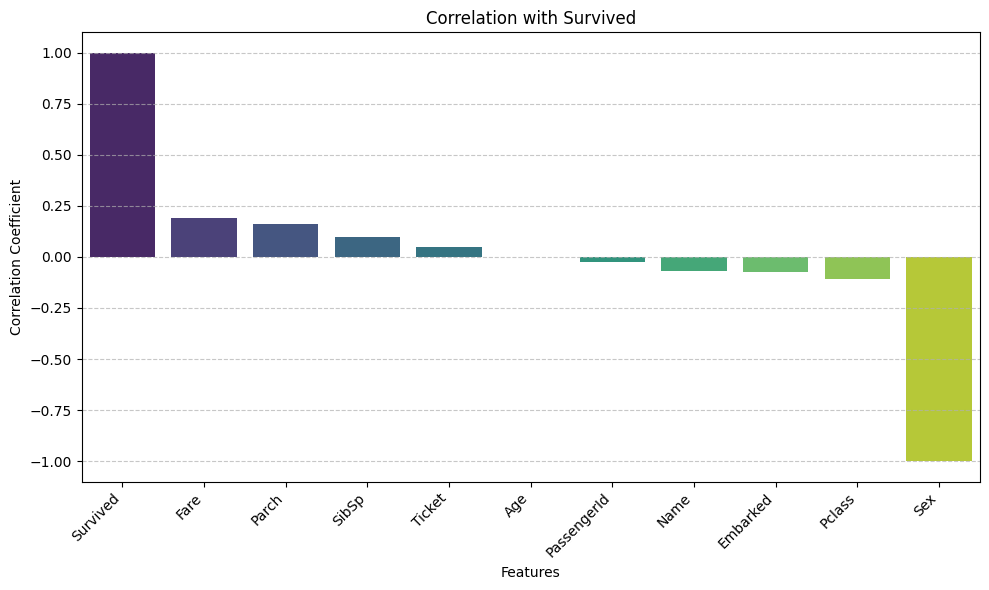

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix again, or use the one from df.corr().T
correlation_matrix = df.corr()

# Sort the correlations with 'Survived' for easier visualization
survived_corr = correlation_matrix['Survived'].sort_values(ascending=False)

# Create a bar plot for correlation with Survived
plt.figure(figsize=(10, 6))
sns.barplot(x=survived_corr.index, y=survived_corr.values, palette='viridis')
plt.title('Correlation with Survived')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

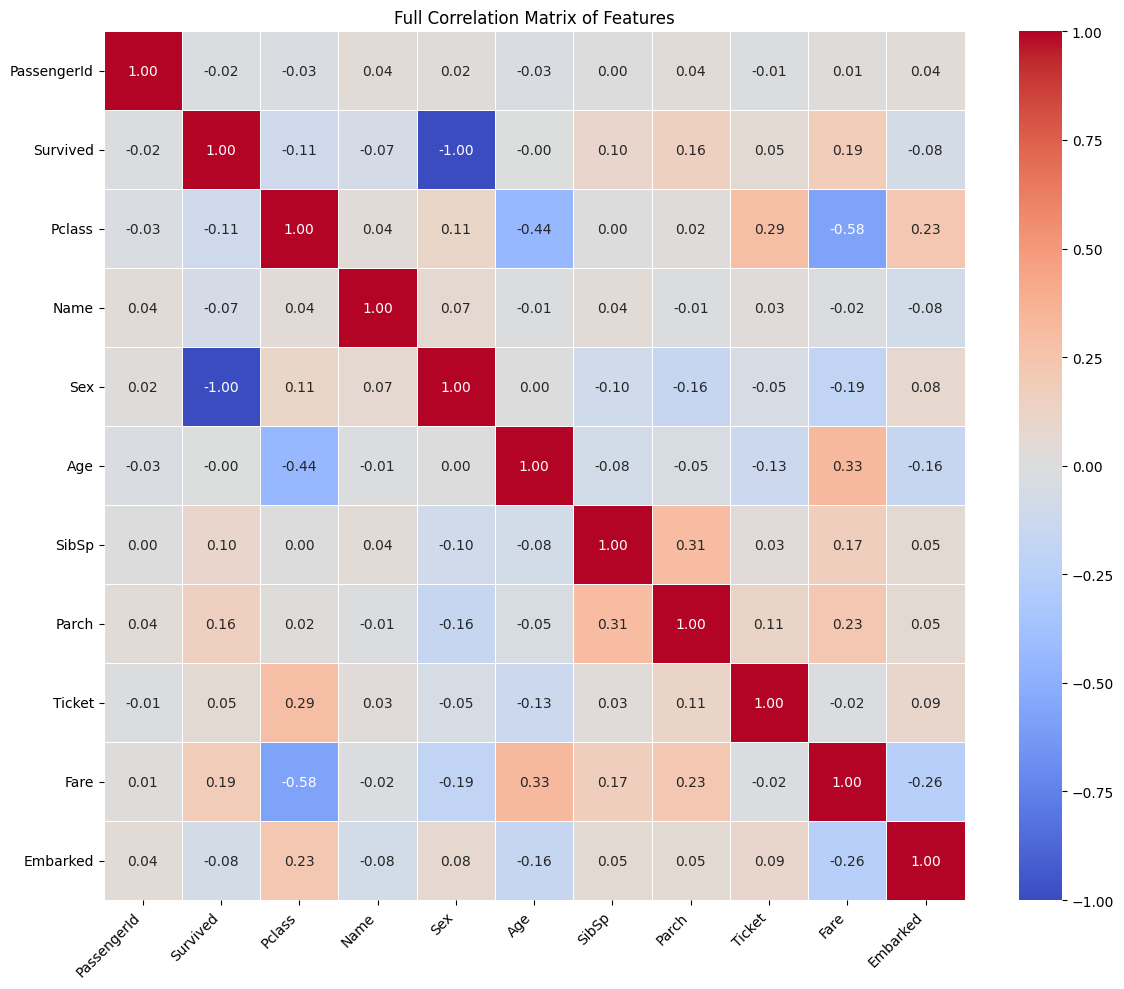

In [22]:
# Alternatively, you can visualize the full correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Full Correlation Matrix of Features')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [24]:
survived_corr = correlation_matrix['Survived'].sort_values(ascending=False)
survived_corr

,Survived
Survived,1.000000
Fare,0.191382
Parch,0.159120
SibSp,0.099943
Ticket,0.047663
Age,-0.000011
PassengerId,-0.023245
Name,-0.067263
Embarked,-0.076281
Pclass,-0.108615


In [25]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [73]:
x = df[['PassengerId', 'Pclass',  'Sex',  'SibSp',
       'Parch', 'Fare']]
y = df['Survived']
y

,Survived
0,0
1,1
2,0
3,0
4,1
...,...
413,0
414,1
415,0
416,0


In [74]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , classification_report

x_train , x_test  , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state = 42)


y_train

,Survived
336,0
31,0
84,0
287,0
317,0
...,...
71,0
106,0
270,0
348,0


Change the max_iter to see changes in the accuracy

In [105]:
model = LogisticRegression(max_iter=40)
model.fit(x_train , y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=40)

In [106]:
y_pred = model.predict(x_test)

In [107]:
y_pred

array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1])

In [108]:
y_test

,Survived
321,0
324,1
388,0
56,0
153,1
...,...
57,0
126,0
24,1
17,0


In [109]:
classification_report(y_test , y_pred)

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00        50\n           1       1.00      1.00      1.00        34\n\n    accuracy                           1.00        84\n   macro avg       1.00      1.00      1.00        84\nweighted avg       1.00      1.00      1.00        84\n'

In [110]:
accuracy_score(y_test , y_pred)

1.0